In [8]:
import pandas as pd

df_csv = pd.read_csv("House prediction project/HousePricePrediction.csv")
df_csv.head()
df_csv.info()
df_csv.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [10]:
df = df_csv

In [12]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2919 non-null   int64  
 1   MSSubClass           2919 non-null   int64  
 2   LotArea              2919 non-null   int64  
 3   OverallCond          2919 non-null   int64  
 4   YearBuilt            2919 non-null   int64  
 5   YearRemodAdd         2919 non-null   int64  
 6   BsmtFinSF2           2918 non-null   float64
 7   TotalBsmtSF          2918 non-null   float64
 8   SalePrice            1460 non-null   float64
 9   MSZoning_FV          2919 non-null   bool   
 10  MSZoning_RH          2919 non-null   bool   
 11  MSZoning_RL          2919 non-null   bool   
 12  MSZoning_RM          2919 non-null   bool   
 13  LotConfig_CulDSac    2919 non-null   bool   
 14  LotConfig_FR2        2919 non-null   bool   
 15  LotConfig_FR3        2919 non-null   b

In [15]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]
X.shape
y.shape

(2919,)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape
X_test.shape

(584, 34)

In [19]:
# Check again
X.isnull().sum().sort_values(ascending=False).head(10)
# Fill missing values with mean
X = X.fillna(X.mean())

In [27]:
# Step 1: Drop missing target
df = df.dropna(subset=["SalePrice"])

# Step 2: Define again
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# Step 3: Fill X
X = X.fillna(X.mean())

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred = model.predict(X_test)

In [31]:
y_pred[:5]
y_test[:5]

892     154500.0
1105    325000.0
413     115000.0
522     159000.0
1036    315500.0
Name: SalePrice, dtype: float64

In [32]:
print("Predicted:", y_pred[:5])
print("Actual:", y_test[:5].values)

Predicted: [168733.00189055 243223.76121104 114785.4122782  157880.21908253
 254517.60086045]
Actual: [154500. 325000. 115000. 159000. 315500.]


In [33]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 34129.486829873305
R2 Score: 0.6196387511449795


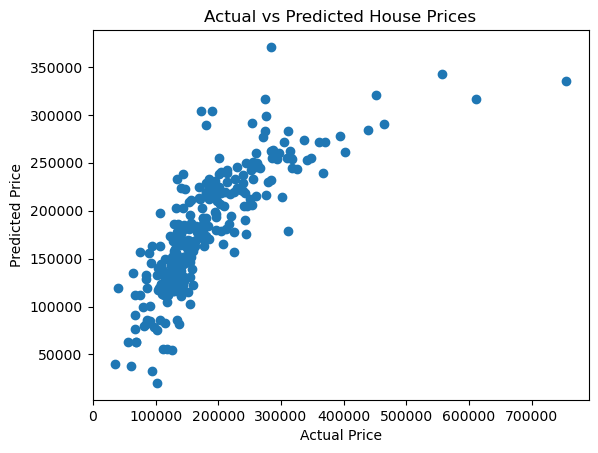

In [34]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [39]:
# Encode
X = pd.get_dummies(X, drop_first=True)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
from sklearn.metrics import mean_absolute_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 34129.486829873305
R2: 0.6196387511449795
